# Specification repair and initialization for Pyomo models

An initialization can be bad in two different ways, and pyomo-pounce
addresses both:

- **a bad specification** — the wrong variables are held, so the
  equality system is structurally singular and *no* starting point
  can save the solve. `block_analyze` diagnoses it,
  `block_repair_plan` plans the fix with no extra input, and
  `initialize` / `block_initialize` repair it automatically;
- **a bad starting point** — the specification is right but the
  values are garbage. The `initialize` pipeline (fill, projection,
  block-triangular solve) builds a consistent starting point, even
  from nothing.

The example is a real flowsheet shape: two 41-stage distillation
columns in series, 569 equations. Requires `pyomo-pounce` with the
incidence extras (`pip install pyomo-pounce networkx scipy`).

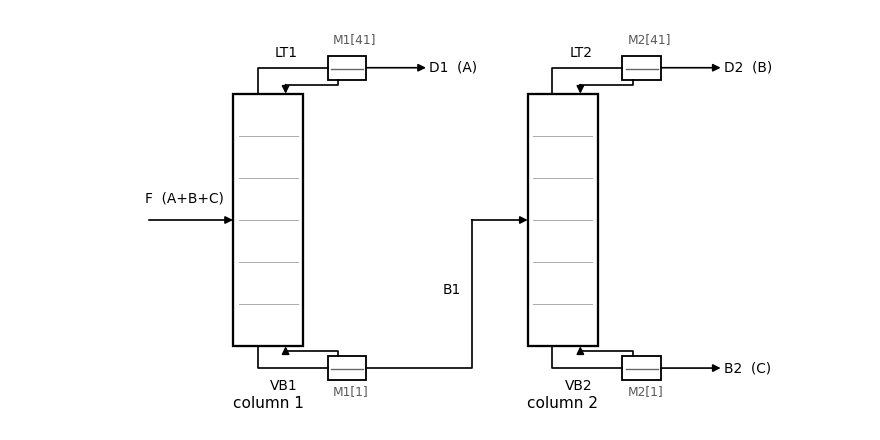

In [1]:
import pyomo.environ as pyo
import pyomo_pounce

## The model

Two 41-stage columns separating a ternary mixture (A light, B
middle, C heavy): column 1 takes A overhead, its bottoms feed
column 2, which takes B overhead and C out the bottom. Constant
relative volatility VLE, constant molar vapor flows, Francis weir
liquid flows, tray temperatures as a linear composition map: the
Skogestad "Column A" lineage, authored directly at steady state
(every balance reads `0 == rhs`).

Two authoring choices matter here. The states and algebraics carry
**no starting values**: unset values reach the solver as zeros, so
this model starts as badly as a model can. And the eight flow
controls (reflux, boilup, distillate, bottoms per column) carry the
operating point you intend to hold: they are the `decisions`.
Nothing else needs declaring; what cannot be held or determined is
found automatically.

In [2]:
def double_column_steady():
    """Two 41-stage columns in series separating a ternary mixture.

    Skogestad "Column A", authored directly at steady state:
    every holdup and composition balance reads 0 == rhs. States and
    algebraics carry no initial values; the controls carry the operating
    point you intend to hold.
    """
    NT, NF = 41, 21
    m = pyo.ConcreteModel()
    m.tray = pyo.Set(initialize=range(1, NT + 1))
    m.comp = pyo.Set(initialize=[1, 2])  # A and B; C is 1 - x_A - x_B
    m.tray_v = pyo.Set(initialize=range(1, NT))
    m.tray_weir = pyo.Set(initialize=range(2, NT))

    m.alpha1 = pyo.Param(initialize=2.0, mutable=True)  # volatility A/B
    m.alpha2 = pyo.Param(initialize=1.5, mutable=True)  # volatility B/C
    m.Kbf = pyo.Param(initialize=29.65032, mutable=True)  # weir constant below feed
    m.Kuf = pyo.Param(initialize=21.65032, mutable=True)  # weir constant above feed
    m.Muw = pyo.Param(initialize=0.25, mutable=True)  # holdup under the weir (kmol)
    m.TbA = pyo.Param(initialize=353.3, mutable=True)  # boiling temperatures (K)
    m.TbB = pyo.Param(initialize=383.8, mutable=True)
    m.TbC = pyo.Param(initialize=411.5, mutable=True)
    m.F = pyo.Param(initialize=1.41, mutable=True)  # feed rate
    m.qF = pyo.Param(initialize=1.0, mutable=True)  # feed liquid fraction
    m.zF1 = pyo.Param(initialize=0.3967941, mutable=True)  # feed composition A
    m.zF2 = pyo.Param(initialize=0.2064117, mutable=True)  # feed composition B

    # states and algebraics: deliberately no starting values
    m.x1 = pyo.Var(m.tray, m.comp, bounds=(0, 1))
    m.x2 = pyo.Var(m.tray, m.comp, bounds=(0, 1))
    m.M1 = pyo.Var(m.tray, bounds=(0.25, 0.75))
    m.M2 = pyo.Var(m.tray, bounds=(0.25, 0.75))
    m.L1 = pyo.Var(m.tray_weir, bounds=(0, None))
    m.L2 = pyo.Var(m.tray_weir, bounds=(0, None))
    m.y1 = pyo.Var(m.tray_v, m.comp, bounds=(0, 1))
    m.y2 = pyo.Var(m.tray_v, m.comp, bounds=(0, 1))
    m.TC1 = pyo.Var(m.tray, bounds=(350, 412))
    m.TC2 = pyo.Var(m.tray, bounds=(350, 412))
    m.purA1 = pyo.Var(bounds=(0.95, None))  # A overhead, column 1
    m.purB2 = pyo.Var(bounds=(0.95, None))  # B overhead, column 2
    m.purC2 = pyo.Var(bounds=(0.95, None))  # C bottoms, column 2

    # controls: reflux, boilup, distillate, bottoms per column, at the
    # reference operating point
    m.LT1 = pyo.Var(bounds=(0, 10), initialize=4.296642)
    m.VB1 = pyo.Var(bounds=(0, 10), initialize=4.858812)
    m.D1 = pyo.Var(bounds=(0, 10), initialize=0.5621708)
    m.B1 = pyo.Var(bounds=(0, 10), initialize=0.8478292)
    m.LT2 = pyo.Var(bounds=(0, 10), initialize=2.41023)
    m.VB2 = pyo.Var(bounds=(0, 10), initialize=2.694203)
    m.D2 = pyo.Var(bounds=(0, 10), initialize=0.2839724)
    m.B2 = pyo.Var(bounds=(0, 10), initialize=0.5638568)

    # vapor flows and condenser liquid flows are the controls acting there
    def V1(m, i):
        return m.VB1 if i <= NF - 1 else m.VB1 + (1 - m.qF) * m.F

    def V2(m, i):
        return m.VB2

    def L1_(m, i):
        return m.LT1 if i == NT else m.L1[i]

    def L2_(m, i):
        return m.LT2 if i == NT else m.L2[i]

    def zF(m, j):
        return m.zF1 if j == 1 else m.zF2

    @m.Constraint(m.tray_weir)  # Francis weir with a smoothed max
    def L1_def(m, i):
        K = m.Kbf if i <= NF else m.Kuf
        return m.L1[i] == K * ((m.M1[i] - m.Muw + pyo.sqrt((m.M1[i] - m.Muw) ** 2 + 1e-8)) / 2) ** 1.5

    @m.Constraint(m.tray_weir)
    def L2_def(m, i):
        K = m.Kbf if i <= NF else m.Kuf
        return m.L2[i] == K * ((m.M2[i] - m.Muw + pyo.sqrt((m.M2[i] - m.Muw) ** 2 + 1e-8)) / 2) ** 1.5

    @m.Constraint(m.tray_v, m.comp)  # constant-volatility VLE, division-free
    def y1_def(m, i, j):
        alpha = m.alpha1 if j == 1 else m.alpha2
        denom = 1 + (m.alpha1 - 1) * m.x1[i, 1] + (m.alpha2 - 1) * m.x1[i, 2]
        return m.y1[i, j] * denom == alpha * m.x1[i, j]

    @m.Constraint(m.tray_v, m.comp)
    def y2_def(m, i, j):
        alpha = m.alpha1 if j == 1 else m.alpha2
        denom = 1 + (m.alpha1 - 1) * m.x2[i, 1] + (m.alpha2 - 1) * m.x2[i, 2]
        return m.y2[i, j] * denom == alpha * m.x2[i, j]

    @m.Constraint(m.tray)  # tray temperature: linear composition map
    def TC1_def(m, i):
        return m.TC1[i] == m.TbA * m.x1[i, 1] + m.TbB * m.x1[i, 2] + m.TbC * (1 - m.x1[i, 1] - m.x1[i, 2])

    @m.Constraint(m.tray)
    def TC2_def(m, i):
        return m.TC2[i] == m.TbA * m.x2[i, 1] + m.TbB * m.x2[i, 2] + m.TbC * (1 - m.x2[i, 1] - m.x2[i, 2])

    @m.Constraint()  # the purity aliases carry the hard spec bounds
    def purA1_def(m):
        return m.purA1 == m.x1[NT, 1]

    @m.Constraint()
    def purB2_def(m):
        return m.purB2 == m.x2[NT, 2]

    @m.Constraint()
    def purC2_def(m):
        return m.purC2 == 1 - m.x2[1, 1] - m.x2[1, 2]

    # holdup and composition balances at rest: 0 == rhs
    @m.Constraint(m.tray)
    def M1_bal(m, i):
        if i == 1:  # reboiler
            return 0 == L1_(m, 2) - V1(m, 1) - m.B1
        if i == NT:  # total condenser
            return 0 == V1(m, NT - 1) - m.LT1 - m.D1
        feed = m.F if i == NF else 0
        return 0 == L1_(m, i + 1) - L1_(m, i) + V1(m, i - 1) - V1(m, i) + feed

    @m.Constraint(m.tray, m.comp)
    def x1_bal(m, i, j):
        if i == 1:
            rhs = L1_(m, 2) * (m.x1[2, j] - m.x1[1, j]) - V1(m, 1) * (m.y1[1, j] - m.x1[1, j])
        elif i == NT:
            rhs = V1(m, NT - 1) * (m.y1[NT - 1, j] - m.x1[NT, j])
        else:
            rhs = (
                L1_(m, i + 1) * (m.x1[i + 1, j] - m.x1[i, j])
                + V1(m, i - 1) * (m.y1[i - 1, j] - m.x1[i, j])
                - V1(m, i) * (m.y1[i, j] - m.x1[i, j])
            )
            if i == NF:
                rhs = rhs + m.F * (zF(m, j) - m.x1[i, j])
        return 0 == rhs / m.M1[i]

    @m.Constraint(m.tray)
    def M2_bal(m, i):
        if i == 1:
            return 0 == L2_(m, 2) - V2(m, 1) - m.B2
        if i == NT:
            return 0 == V2(m, NT - 1) - m.LT2 - m.D2
        feed = m.B1 if i == NF else 0
        return 0 == L2_(m, i + 1) - L2_(m, i) + V2(m, i - 1) - V2(m, i) + feed

    @m.Constraint(m.tray, m.comp)
    def x2_bal(m, i, j):
        if i == 1:
            rhs = L2_(m, 2) * (m.x2[2, j] - m.x2[1, j]) - V2(m, 1) * (m.y2[1, j] - m.x2[1, j])
        elif i == NT:
            rhs = V2(m, NT - 1) * (m.y2[NT - 1, j] - m.x2[NT, j])
        else:
            rhs = (
                L2_(m, i + 1) * (m.x2[i + 1, j] - m.x2[i, j])
                + V2(m, i - 1) * (m.y2[i - 1, j] - m.x2[i, j])
                - V2(m, i) * (m.y2[i, j] - m.x2[i, j])
            )
            if i == NF:  # column 1 bottoms is column 2 feed
                rhs = rhs + m.B1 * (m.x1[1, j] - m.x2[i, j])
        return 0 == rhs / m.M2[i]

    m.obj = pyo.Objective(expr=0)  # a simulation carries no cost
    return m


def controls(m):
    return [m.LT1, m.VB1, m.D1, m.B1, m.LT2, m.VB2, m.D2, m.B2]

## Failure mode 1: a bad specification

Holding all eight flows, the dynamic DOFs, is a natural but naive specification. The solve gets nowhere:

In [3]:
m = double_column_steady()
for v in controls(m):
    v.fix()
res = pyo.SolverFactory("pounce").solve(m, tee=True, load_solutions=False)
print(f"all eight controls held: {res.solver.termination_condition}")

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpn71x3e52.pyomo.nl...
Parsed 569 vars, 

  28r 0.0000000e+00 1.02e-02 1.14e+02   -7.5 1.39e+01      - 7.10e-01 5.41e-01h  1
  29r 0.0000000e+00 5.36e-03 4.42e+01   -7.5 4.91e+00      - 7.85e-01 7.38e-01h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  30r 0.0000000e+00 6.22e-04 4.20e+01   -7.5 1.68e+00      - 7.99e-01 9.23e-01h  1
  31r 0.0000000e+00 1.20e-04 5.43e+01   -7.5 5.94e-01      - 8.70e-01 1.00e+00f  1
  32r 0.0000000e+00 4.66e-05 2.05e-07   -7.5 5.32e-01      - 1.00e+00 1.00e+00h  1
  33r 0.0000000e+00 1.32e-06 1.40e-08   -7.5 5.30e-02      - 1.00e+00 1.00e+00h  1
  34r 0.0000000e+00 8.00e-07 1.52e-11   -7.5 4.42e-03      - 1.00e+00 1.00e+00h  1
  34  0.0000000e+00 8.00e-07 4.51e-04   -5.7 1.70e+01      - 0.00e+00 9.54e-07R 21
  35  0.0000000e+00 1.42e-05 1.17e-04   -5.7 7.86e+00      - 1.00e+00 3.12e-02h  6
  36  0.0000000e+00 2.68e-02 9.59e-06   -5.7 1.20e+01      - 1.00e+00 9.54e-01h  1
  37  0.0000000e+00 7.46e-03 7.16e-07   -5.7 5.79e+00      - 1.00e+00 1.00e+00f  1
  38

  75  0.0000000e+00 1.39e-05 6.15e-05   -8.6 5.35e-01   -5.3 9.72e-01 3.45e-03h  8
  76  0.0000000e+00 1.38e-05 6.01e-05   -8.6 1.59e-01   -4.9 1.00e+00 1.48e-02h  3
  77  0.0000000e+00 1.38e-05 6.01e-05   -8.6 4.48e-01   -5.4 1.07e-01 2.00e-03h  9
  78  0.0000000e+00 1.37e-05 5.91e-05   -8.6 1.75e-01   -4.9 1.00e+00 1.29e-02h  5
  79  0.0000000e+00 1.37e-05 5.91e-05   -8.6 7.16e-01   -5.4 4.85e-02 1.35e-03h  9
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  80  0.0000000e+00 1.36e-05 5.82e-05   -8.6 1.94e-01   -5.0 1.00e+00 1.43e-02h  7
  81  0.0000000e+00 1.36e-05 5.82e-05   -8.6 1.08e+00   -5.5 3.26e-02 1.02e-03h  9
  82  0.0000000e+00 1.36e-05 5.79e-05   -8.6 2.15e-01   -5.0 1.00e+00 6.85e-03h  8
  83  0.0000000e+00 1.36e-05 5.79e-05   -8.6 1.74e+00   -5.5 2.10e-02 7.16e-04h  9
  84  0.0000000e+00 8.95e-04 8.06e-06   -8.6 2.39e-01   -5.1 1.00e+00 8.62e-01w  1
  85  0.0000000e+00 3.54e-04 9.31e-06   -8.6 1.16e-01   -4.7 1.00e+00 6.19e-01w  1
  86

 108  0.0000000e+00 8.13e-06 3.01e-05   -8.6 1.34e-01   -4.8 1.00e+00 2.31e-02h  6
 109  0.0000000e+00 8.12e-06 3.16e-05   -8.6 2.48e-01   -5.3 1.00e+00 4.64e-03h  8
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 110  0.0000000e+00 8.07e-06 3.01e-05   -8.6 1.45e-01   -4.9 1.00e+00 2.00e-02h  6
 111  0.0000000e+00 8.07e-06 3.10e-05   -8.6 2.63e-01   -5.3 1.00e+00 4.81e-03h  8
 112  0.0000000e+00 8.02e-06 3.04e-05   -8.6 1.67e-01   -4.9 1.00e+00 1.75e-02h  6
 113  0.0000000e+00 8.01e-06 2.98e-05   -8.6 3.16e-01   -5.4 4.81e-01 3.54e-03h  8
 114  0.0000000e+00 7.98e-06 3.04e-05   -8.6 1.77e-01   -5.0 1.00e+00 1.60e-02h  6
 115  0.0000000e+00 7.97e-06 2.95e-05   -8.6 6.09e-01   -5.4 1.45e-01 2.01e-03h  8
 116  0.0000000e+00 7.96e-06 3.04e-05   -8.6 1.85e-01   -5.0 1.00e+00 1.50e-02h  6
 117  0.0000000e+00 2.60e-04 3.05e-05   -8.6 5.05e+00   -5.5 1.71e-02 5.05e-02w  1
 118  0.0000000e+00 2.77e-04 3.44e-05   -8.6 4.56e-01   -5.1 3.08e-02 7.49e-01w  1
 119

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 140  0.0000000e+00 7.39e-06 1.94e-05   -8.6 7.61e-02   -4.7 1.00e+00 4.72e-02h  5
 141  0.0000000e+00 7.37e-06 2.11e-05   -8.6 1.84e-01   -5.2 1.00e+00 5.57e-03h  8
 142  0.0000000e+00 7.35e-06 1.87e-05   -8.6 8.17e-02   -4.8 1.00e+00 4.89e-02h  5
 143  0.0000000e+00 3.96e-04 6.52e-06   -8.6 1.98e-01   -5.2 1.00e+00 6.87e-01w  1
 144  0.0000000e+00 1.72e-04 5.13e-06   -8.6 7.66e-02   -4.8 1.00e+00 6.20e-01w  1
 145  0.0000000e+00 1.71e-04 3.54e-06   -8.6 2.36e-01   -5.3 1.00e+00 5.74e-01w  1
 146  0.0000000e+00 7.33e-06 2.07e-05   -8.6 9.12e-02   -4.9 1.00e+00 5.37e-03h  7
 147  0.0000000e+00 7.32e-06 2.13e-05   -8.6 2.40e-01   -5.3 1.00e+00 5.23e-03h  8
 148  0.0000000e+00 7.26e-06 1.93e-05   -8.6 1.07e-01   -4.9 1.00e+00 1.89e-02h  6
 149  0.0000000e+00 7.24e-06 2.10e-05   -8.6 2.96e-01   -5.4 9.18e-01 4.83e-03h  8
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 150

...

2928r 0.0000000e+00 7.13e-06 7.63e-09   -9.0 1.30e-01      - 1.00e+00 1.00e+00h  1
2929r 0.0000000e+00 1.75e-06 4.12e-10   -9.0 6.92e-02      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
2930r 0.0000000e+00 8.00e-07 4.86e-12   -9.0 4.18e-03      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
2930  0.0000000e+00 8.00e-07 1.22e-04   -8.6 3.52e-01   -5.3 0.00e+00 9.54e-07R 21
2931  0.0000000e+00 8.00e-07 3.70e-05   -8.6 1.14e+01      - 6.98e-01 1.95e-03h 10
2932  0.0000000e+00 8.00e-07 2.58e-05   -8.6 1.15e+01      - 3.06e-01 1.95e-03h 10
2933  0.0000000e+00 8.00e-07 2.18e-05   -8.6 1.14e+01      - 1.55e-01 9.77e-04h 11
2934  0.0000000e+00 8.00e-07 1.91e-05   -8.6 1.14e+01      - 1.24e-01 9.77e-04h 11
2935  0.0000000e+00 8.00e-07 1.69e-05   -8.6 1.14e+01      - 1.16e-01 9.77e-04h 11
2936  0.0000000e+00 3.14e-02 1.48e-05   -8.6 1.14e+01      - 1.14e-01 1.00e+00h  1
2937

2951r 0.0000000e+00 8.00e-07 9.99e+02   -6.1 0.00e+00      - 0.00e+00 9.54e-07R 21
2952r 0.0000000e+00 8.00e-07 9.90e+02   -6.1 4.56e+00      - 3.36e-01 9.42e-03f  1
2953r 0.0000000e+00 4.12e-05 6.37e+02   -6.1 1.31e+00      - 1.00e+00 3.57e-01h  1
2954r 0.0000000e+00 6.37e-05 5.89e-07   -6.1 6.89e-01      - 1.00e+00 1.00e+00h  1
2955r 0.0000000e+00 8.84e-07 1.30e-08   -6.1 9.23e-02      - 1.00e+00 1.00e+00h  1
2956r 0.0000000e+00 2.07e-05 2.07e+01   -9.0 3.57e-01      - 9.17e-01 8.26e-01h  1
2957r 0.0000000e+00 2.00e-04 1.66e+02   -9.0 1.29e+00      - 8.54e-01 6.22e-01h  1
2958r 0.0000000e+00 2.60e-04 1.12e+02   -9.0 1.18e+00      - 7.66e-01 6.32e-01h  1
2959r 0.0000000e+00 1.55e-04 3.40e+01   -9.0 8.97e-01      - 6.52e-01 6.97e-01h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
2960r 0.0000000e+00 5.24e-05 1.45e+01   -9.0 6.27e-01      - 7.10e-01 7.39e-01h  1
2961r 0.0000000e+00 2.94e-05 9.76e+00   -9.0 3.00e-01      - 9.40e-01 1.00e+00f  1
2962

2971  0.0000000e+00 5.41e-05 2.68e-07   -8.6 4.74e+00      - 1.00e+00 5.84e-03h  8
2972  0.0000000e+00 5.40e-05 2.31e-07   -8.6 3.19e+00      - 1.00e+00 3.91e-03h  9
2973  0.0000000e+00 5.39e-05 2.30e-07   -8.6 3.07e+00      - 1.00e+00 4.88e-04h 12
2974  0.0000000e+00 5.39e-05 2.30e-07   -8.6 3.01e+00      - 1.00e+00 3.05e-05h 16
2975  0.0000000e+00 5.39e-05 2.31e-07   -8.6 2.98e+00      - 1.00e+00 1.53e-05h 17
2976r 0.0000000e+00 5.39e-05 9.99e+02   -4.3 0.00e+00      - 0.00e+00 9.54e-07R 21
2977r 0.0000000e+00 1.36e-05 9.89e+02   -4.3 9.57e+01      - 7.67e-01 9.90e-04f  1
2978r 0.0000000e+00 2.01e-03 2.21e+02   -4.3 3.28e+00      - 1.00e+00 7.63e-01f  1
2979r 0.0000000e+00 1.29e-03 6.21e-06   -4.3 2.08e+00      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
2980r 0.0000000e+00 7.03e-06 8.01e-08   -4.3 3.76e-01      - 1.00e+00 1.00e+00h  1
2981r 0.0000000e+00 1.69e-05 1.95e+01   -6.4 2.64e-01      - 9.98e-01 8.82e-01f  1
2982

2996  0.0000000e+00 2.21e-03 1.23e-07   -8.6 3.87e+00      - 1.00e+00 5.00e-01h  2
2997  0.0000000e+00 1.67e-03 1.66e-07   -8.6 3.73e+00      - 1.00e+00 2.50e-01h  3
2998  0.0000000e+00 1.56e-03 1.99e-07   -8.6 3.53e+00      - 1.00e+00 6.25e-02h  5
2999  0.0000000e+00 1.54e-03 2.09e-07   -8.6 3.39e+00      - 1.00e+00 1.56e-02h  7
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
3000  0.0000000e+00 1.54e-03 2.11e-07   -8.6 3.35e+00      - 1.00e+00 1.95e-03h 10


Number of Iterations....: 3000

                                   (scaled)                 (unscaled)
Objective...............:   0.0000000000000000e+00    0.0000000000000000e+00
Dual infeasibility......:   2.1131319298069368e-07    2.1131319298069368e-07
Constraint violation....:   1.5369306727002208e-03    1.5369306727002208e-03
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   3.1968554859918819e-09    3.1968554859918819e-09
Overall NLP 

all eight controls held: maxIterations


`block_analyze` shows why, and why no starting point could have
helped. The system is 569 by 569 with the controls held: square by
count, singular in structure. Four specifications are missing on
one side (the condenser and reboiler levels of both columns appear
in no solvable equation) while four are surplus on the other (with
every flow pinned, the 82 tray holdup balances fight over 78
internal liquid flows). The two defects cancel in the count and the
partition exposes both:

In [4]:
m = double_column_steady()
print(pyomo_pounce.block_analyze(m, decisions=controls(m)))

pyomo-pounce block_analyze
  decisions fixed   : 8
  equality system   : 569 constraints, 569 variables
  system square     : False
  square part       : 78 variables in 78 blocks (78 1x1)
  underconstrained  : 413 variables, 409 constraints (4 more specifications needed)
    vars (specify or flag as decisions): M1[1], M1[41], M2[1], M2[41], y1[1,1], y1[1,2], x1[1,1], y1[2,1], x1[1,2], y1[2,2], ... and 403 more
    cons: x1_bal[1,1], x1_bal[1,2], y1_def[1,1], x1_bal[2,1], y1_def[1,2], x1_bal[2,2], TC1_def[1], x2_bal[21,1], y1_def[2,1], x1_bal[3,1], ... and 399 more
  overconstrained   : 82 constraints, 78 variables (4 redundant/conflicting)
    cons (redundant/conflicting specs): M1_bal[40], M1_bal[41], M2_bal[40], M2_bal[41], M1_bal[39], M1_bal[38], M1_bal[37], M1_bal[36], M1_bal[35], M1_bal[34], ... and 72 more
    vars: L1[40], L1[39], L1[38], L1[37], L1[36], L1[35], L1[34], L1[33], L1[32], L1[31], ... and 68 more


## The repair plan

`block_repair_plan` plans a valid specification instead of failing
on the broken one. The candidates are pruned to the subset a square
system can hold: matching prefers plain variables over candidates,
which provably minimizes the number pruned. The pins need no user
input at all: a variable is pinned when every one of its edges is
provably unusable, the key case being an equation `0 == f/g`, which
cannot determine a variable appearing only in the denominator `g`
(its sensitivity there vanishes at every solution). That is exactly
the shape of these composition balances, `0 == rhs/M`, so the four
drum levels are identified canonically, while the weir-coupled tray
levels keep real edges and stay free. It is a plan, not an action:
nothing on the model is touched:

In [5]:
plan = pyomo_pounce.block_repair_plan(
    m, decision_candidates=controls(m))
print(plan)

pyomo-pounce block_repair_plan
  equality system   : 569 constraints, 577 variables
  repaired square   : True
  decisions         : 4 selected, 4 pruned
    pruned (solved for): D1, B1, D2, B2
  pinned            : 4 undetermined by the equalities, hold at chosen values: M1[1], M1[41], M2[1], M2[41]


Which four controls get pruned follows the candidate listing order:
earlier-listed candidates are preferentially kept, and the model lists
reflux and boilup before the draws, so the plan keeps LT and VB and
prunes the draws, the textbook LV configuration. Any pruned set that
breaks the redundancy would be valid (the columns are coupled, so even
holding both column-2 draws works: they determine column 2's feed,
which is column 1's bottoms). Fixing a control yourself removes it
from the plan entirely, so the choice stays yours when it matters.

## One call: the repair is automatic inside `initialize`

In practice you do not run the plan by hand. With the default
`repair="auto"`, `initialize` checks the specification first: square
means your decisions are used as-is; broken means they become the
candidate pool, the plan is applied, and `report.repair` says what
happened (`repair="off"` reports instead of repairing). The repair
is call-scoped, fixed flags restored
afterwards, so applying the plan to the model you intend to solve
stays an explicit modeling step: fix the plan's decisions and
pins, leave the pruned controls free:

In [6]:
m3 = double_column_steady()
report = pyomo_pounce.initialize(m3, decisions=controls(m3))
print(report)

for v in report.repair.decisions + report.repair.pinned:
    v.fix()
res = pyo.SolverFactory("pounce").solve(m3, tee=True)
print()
print(f"solve: {res.solver.termination_condition}")
print(f"purities: A overhead = {pyo.value(m3.purA1):.5f}, B overhead = {pyo.value(m3.purB2):.5f}, C bottoms = {pyo.value(m3.purC2):.5f}")

pyomo-pounce initialize (fill -> repair -> block-solve)
  decisions held: 4
  pins held     : 4
  spec repair   : 4 pruned (D1, B1, D2, B2), 4 pinned (M1[1], M1[41], M2[1], M2[41])
  values filled : 565
  projection    : optimal
  pyomo-pounce block_initialize
    decisions fixed   : 0
    system square     : True
    blocks solved     : 247 (245 by Newton 1x1, 2 subsystem solves)
    vars initialized  : 569
    left untouched    : 0 underdetermined, 0 overdetermined


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpp_di736a.pyomo.nl...
Parsed 569 vars, 

   5  0.0000000e+00 1.13e-11 1.75e-09   -5.7 2.96e-09      - 1.00e+00 1.00e+00H  1
   6  0.0000000e+00 1.98e-12 1.77e-11   -8.6 2.90e-09      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 6

                                   (scaled)                 (unscaled)
Objective...............:   0.0000000000000000e+00    0.0000000000000000e+00
Dual infeasibility......:   1.7659562993790207e-11    1.7659562993790207e-11
Constraint violation....:   1.9825786446237055e-12    1.9825786446237055e-12
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059047507898542e-09    2.5059047507898542e-09
Overall NLP error.......:   2.5059047507898542e-09    2.5059047507898542e-09


Number of objective function evaluations             = 9
Number of objective gradient evaluations             = 8
Number of equality constraint evaluations            = 9
Number of inequality constraint evaluations          = 9
Number of equality constraint Jacobian e


solve: optimal
purities: A overhead = 0.97994, B overhead = 0.96404, C bottoms = 0.98935


## Failure mode 2: a bad starting point

The other way an initialization goes bad. Keep the repaired
specification, but set every free variable to zero: no vapor
flowing, uniform zero compositions, holdups outside their bounds.
The specification is correct and the solve still dies:

In [7]:
m4 = double_column_steady()
for v in plan.decisions:
    m4.find_component(v.name).fix()
for v in plan.pinned:
    m4.find_component(v.name).fix(0.5)
for v in m4.component_data_objects(pyo.Var):
    if not v.fixed:
        v.set_value(0.0, skip_validation=True)
res = pyo.SolverFactory("pounce").solve(m4, tee=True, load_solutions=False)
print(f"repaired specification, zero start: {res.solver.termination_condition}")

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpivc39t3q.pyomo.nl...
Parsed 569 vars, 

   1  0.0000000e+00 5.97e+01 1.91e+02   -1.0 1.33e+02      - 1.77e-03 4.93e-03f  1
   2  0.0000000e+00 5.97e+01 1.91e+02   -1.0 9.86e+01      - 7.88e-03 6.56e-05h  1
   3r 0.0000000e+00 5.97e+01 9.99e+02    1.8 0.00e+00      - 0.00e+00 6.57e-07R  1
   4r 0.0000000e+00 5.83e+01 9.99e+02    1.8 2.18e+04      - 4.39e-05 4.35e-04f  1
   5r 0.0000000e+00 5.35e+01 9.99e+02    1.1 5.11e+04      - 8.71e-05 8.40e-04f  1
   6r 0.0000000e+00 4.85e+01 9.98e+02    1.1 3.25e+04      - 4.82e-04 4.13e-04f  1
   7r 0.0000000e+00 3.50e+01 9.98e+02    1.1 2.31e+04      - 3.24e-04 6.12e-04f  1
   8r 0.0000000e+00 3.26e+01 9.95e+02    1.1 1.08e+03    0.0 4.79e-02 4.19e-03f  1
   9r 0.0000000e+00 2.39e+01 9.95e+02    1.1 2.61e+03   -0.5 3.77e-03 5.88e-03f  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10r 0.0000000e+00 1.69e+01 9.94e+02    1.1 7.68e+02   -0.1 5.12e-03 9.47e-03f  1


  11r 0.0000000e+00 4.22e+00 9.91e+02    1.1 4.26e+03      - 2.48e-03 3.93e-03f  1
  12r 0.0000000e+00 4.16e+00 9.83e+02    1.1 2.13e+02      - 8.56e-03 5.16e-03f  1
  13r 0.0000000e+00 3.87e+00 9.71e+02    1.1 2.93e+02      - 1.23e-02 1.72e-02f  1
  14r 0.0000000e+00 3.46e+00 9.49e+02    1.1 5.73e+02      - 2.22e-02 2.99e-02f  1
  15r 0.0000000e+00 3.25e+00 9.36e+02    1.1 1.61e+03      - 1.33e-02 1.58e-02f  1
  16r 0.0000000e+00 2.91e+00 8.98e+02    1.1 2.44e+02      - 4.07e-02 3.93e-02f  1
  17r 0.0000000e+00 2.02e+00 8.69e+02    1.1 3.50e+02      - 3.19e-02 9.84e-02f  1
  18r 0.0000000e+00 1.81e+00 8.69e+02    1.1 3.32e+03      - 6.41e-04 1.28e-02f  1
  19r 0.0000000e+00 1.23e+00 7.84e+02    1.1 2.34e+02      - 9.76e-02 6.68e-02f  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  20r 0.0000000e+00 9.69e-01 7.68e+02    1.1 8.99e+01      - 2.00e-02 1.01e-01f  1
  21r 0.0000000e+00 8.15e-01 5.47e+02    1.1 5.57e+01      - 3.70e-01 1.59e-01f  1
  22

  42r 0.0000000e+00 4.63e-02 2.11e+02   -8.7 8.75e+00      - 4.17e-01 3.24e-01h  1
  43r 0.0000000e+00 3.51e-02 1.37e+02   -8.7 1.13e+01      - 3.49e-01 2.79e-01h  1
  44r 0.0000000e+00 9.07e-03 1.45e+02   -8.7 4.24e+00      - 3.91e-01 7.49e-01f  1
  45r 0.0000000e+00 6.88e-03 1.07e+02   -8.7 3.69e+00      - 5.50e-01 2.54e-01h  1
  46r 0.0000000e+00 2.19e-03 1.73e+01   -8.7 2.55e+00      - 7.45e-01 8.20e-01f  1
  47r 0.0000000e+00 1.27e-03 1.02e+02   -8.7 6.97e-01      - 1.00e+00 4.17e-01h  1
  48r 0.0000000e+00 1.87e-04 1.98e-08   -8.7 7.28e-01      - 1.00e+00 1.00e+00f  1
  49r 0.0000000e+00 9.03e-06 2.20e-09   -8.7 1.58e-01      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  50r 0.0000000e+00 4.75e-08 1.38e-10   -8.7 1.10e-02      - 1.00e+00 1.00e+00h  1
  51r 0.0000000e+00 1.48e-08 1.11e-12   -8.7 1.09e-04      - 1.00e+00 1.00e+00h  1
  51  0.0000000e+00 1.48e-08 6.83e+02   -1.0 9.85e+01      - 0.00e+00 6.57e-07R  1
  52

  67r 0.0000000e+00 4.34e-03 1.00e-05   -5.7 3.03e+00      - 1.00e+00 1.00e+00h  1
  68r 0.0000000e+00 1.77e-04 5.19e-07   -5.7 6.69e-01      - 1.00e+00 1.00e+00h  1
  69r 0.0000000e+00 2.71e-06 6.01e-09   -5.7 8.53e-02      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  70r 0.0000000e+00 7.33e-05 2.61e+01   -8.6 5.52e-01      - 9.07e-01 8.20e-01h  1
  71r 0.0000000e+00 5.83e-03 1.16e+02   -8.6 7.03e+00      - 4.25e-01 5.63e-01h  1
  72r 0.0000000e+00 3.28e-03 3.89e+01   -8.6 2.58e+00      - 6.53e-01 6.50e-01h  1
  73r 0.0000000e+00 1.44e-03 1.10e+02   -8.6 1.03e+00      - 8.13e-01 5.89e-01h  1
  74r 0.0000000e+00 4.19e-04 4.83e+01   -8.6 1.22e+00      - 7.17e-01 9.11e-01h  1
  75r 0.0000000e+00 8.41e-05 2.41e-08   -8.6 4.78e-01      - 1.00e+00 1.00e+00h  1
  76r 0.0000000e+00 1.22e-05 1.88e-09   -8.6 1.89e-01      - 1.00e+00 1.00e+00h  1
  77r 0.0000000e+00 1.10e-07 5.97e-11   -8.6 1.59e-02      - 1.00e+00 1.00e+00h  1
  78

...

 144r 0.0000000e+00 1.23e-03 1.24e+02   -8.6 3.05e+00      - 8.40e-01 6.13e-01h  1
 145r 0.0000000e+00 4.32e-04 1.28e+02   -8.6 1.40e+00      - 9.51e-01 7.35e-01h  1
 146r 0.0000000e+00 2.59e-04 8.38e+01   -8.6 8.57e-01      - 5.59e-01 8.92e-01h  1
 147r 0.0000000e+00 8.31e-05 4.88e+01   -8.6 4.34e-01      - 8.46e-01 1.00e+00h  1
 148r 0.0000000e+00 2.56e-05 6.84e-09   -8.6 2.21e-01      - 1.00e+00 1.00e+00h  1
 149r 0.0000000e+00 7.29e-07 1.81e-10   -8.6 3.95e-02      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 150r 0.0000000e+00 5.66e-09 8.21e-13   -8.6 1.75e-03      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 150  0.0000000e+00 5.66e-09 1.00e+00   -1.0 9.27e+01      - 0.00e+00 9.06e-07R  7
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 6.00e+01 1.00e+00   -1.0 0.00e+00      - 0.00e+00 0.00e+00   0
   1

  43r 0.0000000e+00 3.51e-02 1.37e+02   -8.7 1.13e+01      - 3.49e-01 2.79e-01h  1
  44r 0.0000000e+00 9.07e-03 1.45e+02   -8.7 4.24e+00      - 3.91e-01 7.49e-01f  1
  45r 0.0000000e+00 6.88e-03 1.07e+02   -8.7 3.69e+00      - 5.50e-01 2.54e-01h  1
  46r 0.0000000e+00 2.19e-03 1.73e+01   -8.7 2.55e+00      - 7.45e-01 8.20e-01f  1
  47r 0.0000000e+00 1.27e-03 1.02e+02   -8.7 6.97e-01      - 1.00e+00 4.17e-01h  1
  48r 0.0000000e+00 1.87e-04 1.98e-08   -8.7 7.28e-01      - 1.00e+00 1.00e+00f  1
  49r 0.0000000e+00 9.03e-06 2.20e-09   -8.7 1.58e-01      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  50r 0.0000000e+00 4.75e-08 1.38e-10   -8.7 1.10e-02      - 1.00e+00 1.00e+00h  1
  51r 0.0000000e+00 1.48e-08 1.11e-12   -8.7 1.09e-04      - 1.00e+00 1.00e+00h  1
  51  0.0000000e+00 1.48e-08 6.83e+02   -1.0 9.85e+01      - 0.00e+00 6.57e-07R  1
  52r 0.0000000e+00 1.48e-08 6.83e+02   -1.0 0.00e+00      - 0.00e+00 5.15e-07R  5
  53

  91r 0.0000000e+00 7.88e-04 2.04e-06   -5.7 1.21e+00      - 1.00e+00 1.00e+00h  1
  92r 0.0000000e+00 7.45e-05 7.28e-08   -5.7 3.57e-01      - 1.00e+00 1.00e+00h  1
  93r 0.0000000e+00 1.62e-06 4.09e-09   -5.7 5.45e-02      - 1.00e+00 1.00e+00h  1
  94r 0.0000000e+00 4.68e-05 3.10e+01   -8.6 4.88e-01      - 9.10e-01 8.09e-01h  1
  95r 0.0000000e+00 2.11e-03 5.50e+01   -8.6 3.73e+00      - 5.19e-01 6.12e-01h  1
  96r 0.0000000e+00 7.56e-04 6.61e+01   -8.6 1.08e+00      - 8.38e-01 6.99e-01h  1
  97r 0.0000000e+00 3.43e-04 5.61e+01   -8.6 1.08e+00      - 7.13e-01 8.68e-01h  1
  98r 0.0000000e+00 2.38e-04 1.20e+02   -8.6 7.51e-01      - 6.69e-01 1.00e+00h  1
  99r 0.0000000e+00 3.23e-05 1.47e-08   -8.6 2.73e-01      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 100r 0.0000000e+00 1.57e-06 6.88e-10   -8.6 6.27e-02      - 1.00e+00 1.00e+00h  1
 101r 0.0000000e+00 7.83e-09 7.42e-12   -8.6 3.00e-03      - 1.00e+00 1.00e+00h  1
 101

 139r 0.0000000e+00 1.25e-02 1.17e-05   -5.7 6.74e+00      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 140r 0.0000000e+00 7.67e-04 2.01e-06   -5.7 1.20e+00      - 1.00e+00 1.00e+00h  1
 141r 0.0000000e+00 8.16e-05 6.45e-08   -5.7 3.84e-01      - 1.00e+00 1.00e+00h  1
 142r 0.0000000e+00 2.03e-06 4.13e-09   -5.7 6.32e-02      - 1.00e+00 1.00e+00h  1
 143r 0.0000000e+00 4.00e-05 1.90e+01   -8.6 4.58e-01      - 9.24e-01 8.46e-01h  1
 144r 0.0000000e+00 1.23e-03 1.24e+02   -8.6 3.05e+00      - 8.40e-01 6.13e-01h  1
 145r 0.0000000e+00 4.32e-04 1.28e+02   -8.6 1.40e+00      - 9.51e-01 7.35e-01h  1
 146r 0.0000000e+00 2.59e-04 8.38e+01   -8.6 8.57e-01      - 5.59e-01 8.92e-01h  1
 147r 0.0000000e+00 8.31e-05 4.88e+01   -8.6 4.34e-01      - 8.46e-01 1.00e+00h  1
 148r 0.0000000e+00 2.56e-05 6.84e-09   -8.6 2.21e-01      - 1.00e+00 1.00e+00h  1
 149r 0.0000000e+00 7.29e-07 1.81e-10   -8.6 3.95e-02      - 1.00e+00 1.00e+00h  1
iter

repaired specification, zero start: infeasible


The pipeline rescues it. Note the honesty of the report: the
projection stage fails from zero the same way the raw solve did,
and the pipeline warns and moves past it. The block-triangular
solve is what does the work: it solves the equality blocks one at a
time in calculation order, overwriting the zeros exactly, so it
does not care how bad the start is:

In [8]:
report = pyomo_pounce.initialize(m4)
print(report)

res = pyo.SolverFactory("pounce").solve(m4, tee=True)
print()
print(f"zero start, initialized: {res.solver.termination_condition}")
print(f"purities: A overhead = {pyo.value(m4.purA1):.5f}, B overhead = {pyo.value(m4.purB2):.5f}, C bottoms = {pyo.value(m4.purC2):.5f}")

model.name="unknown";
    - termination condition: infeasible
    - message from solver: POUNCE 0.8.0\x3a InfeasibleProblemDetected


pyomo-pounce initialize (fill -> repair -> block-solve)
  decisions held: 0
  values filled : 0
  projection    : infeasible
  pyomo-pounce block_initialize
    decisions fixed   : 0
    system square     : True
    blocks solved     : 247 (245 by Newton 1x1, 2 subsystem solves)
    vars initialized  : 569
    left untouched    : 0 underdetermined, 0 overdetermined


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpf3jeywmr.pyomo.nl...
Parsed 569 vars, 

   2  0.0000000e+00 5.34e-05 4.99e+00   -1.0 3.97e-02      - 1.00e+00 9.95e-01h  1
   3  0.0000000e+00 1.29e-10 5.38e-02   -1.0 4.70e-04      - 1.00e+00 1.00e+00h  1
   4  0.0000000e+00 6.75e-13 2.09e-06   -3.8 1.67e-08      - 1.00e+00 1.00e+00h  1
   5  0.0000000e+00 1.72e-11 1.29e-09   -5.7 2.75e-09      - 1.00e+00 1.00e+00h  1
   6  0.0000000e+00 1.97e-12 1.92e-11   -8.6 3.24e-09      - 1.00e+00 1.00e+00h  1


Number of Iterations....: 6

                                   (scaled)                 (unscaled)
Objective...............:   0.0000000000000000e+00    0.0000000000000000e+00
Dual infeasibility......:   1.9180201670616556e-11    1.9180201670616556e-11
Constraint violation....:   1.9732575810431520e-12    1.9732575810431520e-12
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059048824218256e-09    2.5059048824218256e-09
Overall NLP error.......:   2.5059048824218256e-09    2.5059048824218256e-09


Number of objective


zero start, initialized: optimal
purities: A overhead = 0.97994, B overhead = 0.96404, C bottoms = 0.98935
